# Task 03 - Regressão: volume, visibilidade e engajamento

Este notebook usa o dataset real **contempArt** para fazer uma análise de **regressão**, ou seja, testar relações entre variáveis numéricas.

Em termos simples, a regressão tenta responder: **quando uma métrica aumenta, outra também tende a aumentar ou diminuir?**

## Pergunta principal

> Métricas digitais como quantidade de posts, imagens registradas e seguidores ajudam a explicar visibilidade e engajamento dos artistas?

## O que está sendo analisado

- **Posts x seguidores:** artistas que publicam mais tendem a ter mais seguidores?
- **Imagens registradas x seguidores:** artistas com mais obras/imagens documentadas tendem a ter mais seguidores?
- **Seguidores x média de curtidas:** artistas com mais seguidores tendem a receber mais curtidas?
- **Posts x taxa de engajamento:** publicar mais está associado a maior ou menor engajamento proporcional?

## Importância para o FlowCarreiras

O objetivo não é prever sucesso artístico nem medir qualidade. O objetivo é mostrar se popularidade digital explica bem a visibilidade. Se os modelos tiverem muita variação e baixo poder explicativo, isso reforça que o FlowCarreiras **não deve ranquear artistas apenas por posts, seguidores ou curtidas**. A plataforma deve considerar também organização do perfil, portfólio, interesses, áreas de atuação e oportunidades.

As regressões são exploratórias: elas indicam tendências, mas **não demonstram causalidade**.


In [1]:
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
from sklearn.model_selection import train_test_split

sns.set_theme(style="whitegrid", palette="deep")
pd.set_option("display.max_columns", 50)

DATA_PATH = Path("../data/processed/contempart_artists_enriquecido.csv")
df = pd.read_csv(DATA_PATH)
print(f"Registros carregados: {len(df)}")


Registros carregados: 441


## 1. Preparação e critérios

- Valores ausentes não são transformados em zero.
- Relações muito assimétricas usam `log1p`, preservando zeros válidos e reduzindo o peso de valores extremos.
- Cada regressão usa somente registros válidos para suas duas variáveis.
- A avaliação principal separa treino e teste para evitar medir o modelo apenas nos dados usados no ajuste.


In [2]:
relacoes = [
    ("posts_count", "follower_count", "Posts x seguidores"),
    ("img_count", "follower_count", "Imagens registradas x seguidores"),
    ("follower_count", "avg_likes", "Seguidores x média de curtidas"),
    ("posts_count", "taxa_engajamento", "Posts x taxa de engajamento"),
]

resumo_validade = []
for x, y, titulo in relacoes:
    validos = df[[x, y]].dropna()
    resumo_validade.append({
        "relação": titulo,
        "registros_válidos": len(validos),
        "ausentes_excluídos": len(df) - len(validos),
    })

pd.DataFrame(resumo_validade)


,relação,registros_válidos,ausentes_excluídos
0,Posts x seguidores,359,82
1,Imagens registradas x seguidores,359,82
2,Seguidores x média de curtidas,200,241
3,Posts x taxa de engajamento,200,241


## 2. Dispersões e linhas de tendência

Os eixos usam transformação logarítmica para tornar os padrões visíveis sem permitir que poucos valores extremos dominem os gráficos.


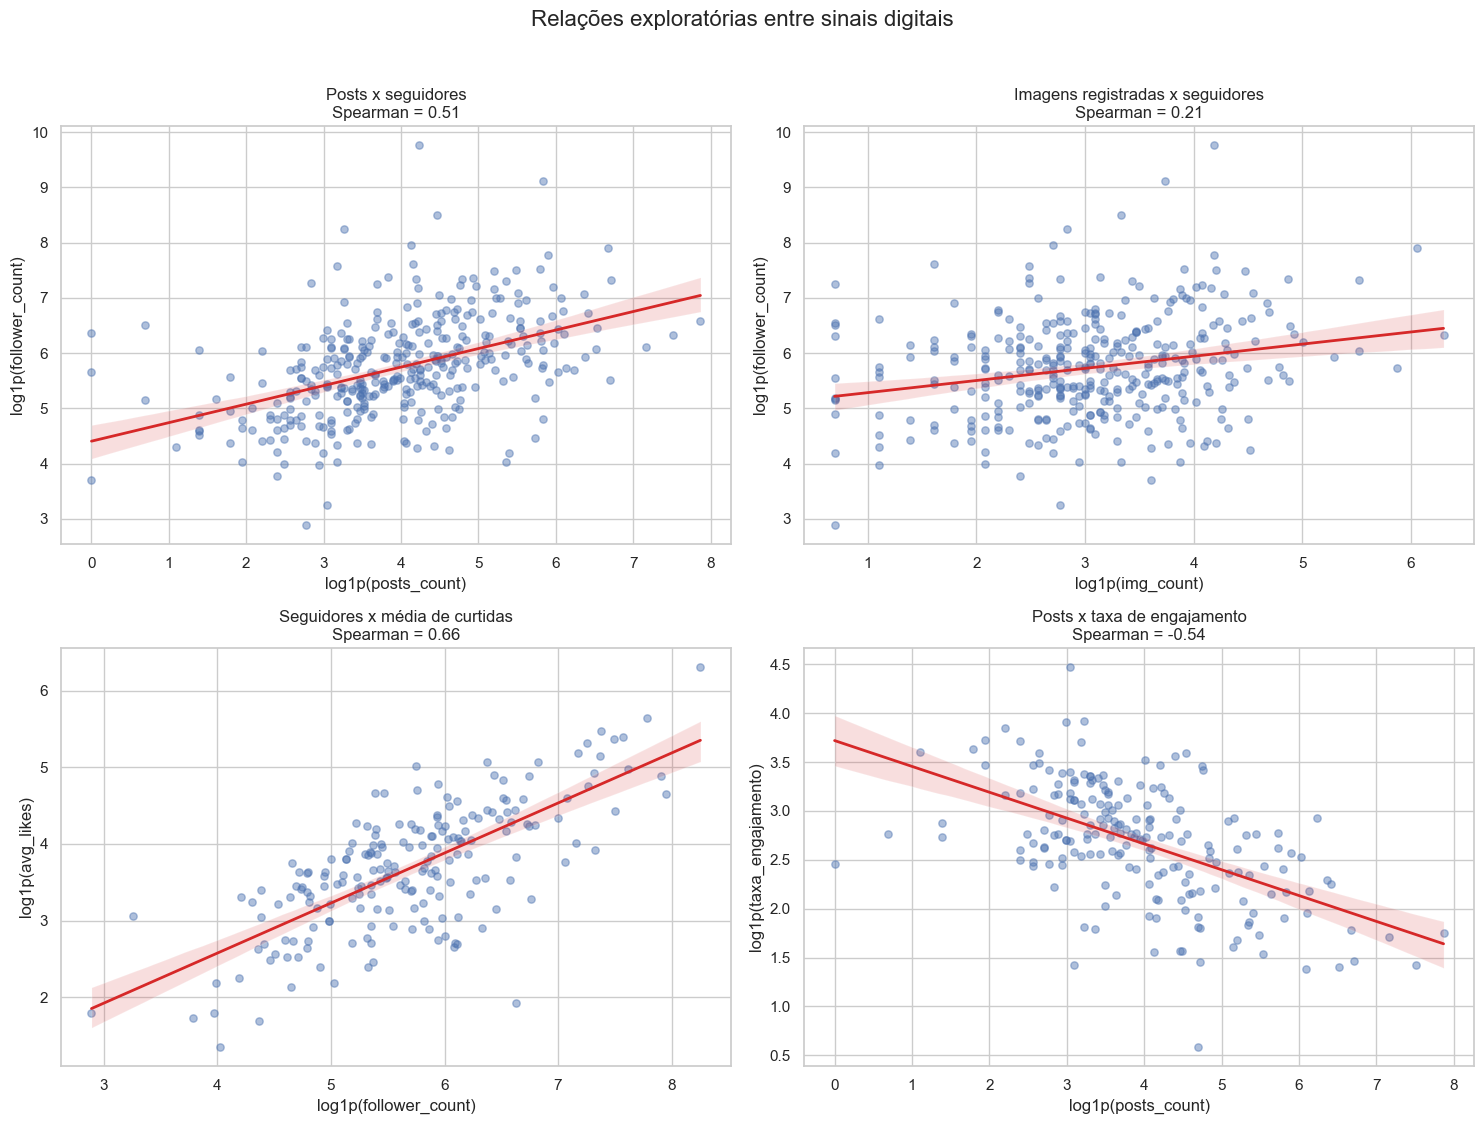

In [3]:
fig, axes = plt.subplots(2, 2, figsize=(15, 11))

for ax, (x, y, titulo) in zip(axes.flat, relacoes):
    dados = df[[x, y]].dropna().copy()
    dados[f"log_{x}"] = np.log1p(dados[x])
    dados[f"log_{y}"] = np.log1p(dados[y])
    sns.regplot(
        data=dados, x=f"log_{x}", y=f"log_{y}", ax=ax,
        scatter_kws={"alpha": 0.45, "s": 28},
        line_kws={"color": "#d62828", "linewidth": 2},
    )
    correlacao = dados[[x, y]].corr(method="spearman").iloc[0, 1]
    ax.set_title(f"{titulo}\nSpearman = {correlacao:.2f}")
    ax.set_xlabel(f"log1p({x})")
    ax.set_ylabel(f"log1p({y})")

plt.suptitle("Relações exploratórias entre sinais digitais", fontsize=16, y=1.02)
plt.tight_layout()
plt.show()


**Interpretação:** linhas ascendentes indicam associação positiva, mas a dispersão ao redor delas mostra que volume de publicação não explica sozinho visibilidade ou engajamento. Para o FlowCarreiras, isso reforça que descoberta e recomendações não devem ser ordenadas somente por popularidade.


## 3. Regressões simples e métricas

As quatro relações são modeladas separadamente. As métricas são calculadas na escala logarítmica:

- **R²:** proporção da variação explicada pelo modelo;
- **MAE:** erro absoluto médio;
- **RMSE:** penaliza erros maiores.


In [4]:
resultados = []
modelos = {}

for x, y, titulo in relacoes:
    dados = df[[x, y]].dropna().copy()
    X = np.log1p(dados[[x]])
    alvo = np.log1p(dados[y])
    X_treino, X_teste, y_treino, y_teste = train_test_split(
        X, alvo, test_size=0.25, random_state=42
    )
    modelo = LinearRegression().fit(X_treino, y_treino)
    predicao = modelo.predict(X_teste)
    resultados.append({
        "relação": titulo,
        "n": len(dados),
        "coeficiente": modelo.coef_[0],
        "intercepto": modelo.intercept_,
        "R²_teste": r2_score(y_teste, predicao),
        "MAE_teste": mean_absolute_error(y_teste, predicao),
        "RMSE_teste": mean_squared_error(y_teste, predicao) ** 0.5,
    })
    modelos[titulo] = {
        "modelo": modelo,
        "X_teste": X_teste,
        "y_teste": y_teste,
        "predicao": predicao,
    }

resultados_regressao = pd.DataFrame(resultados)
display(resultados_regressao.round(3))


,relação,n,coeficiente,intercepto,R²_teste,MAE_teste,RMSE_teste
0,Posts x seguidores,359,0.358,4.290,0.148,0.685,0.909
1,Imagens registradas x seguidores,359,0.237,4.993,0.024,0.758,0.972
2,Seguidores x média de curtidas,200,0.660,-0.053,0.416,0.456,0.620
3,Posts x taxa de engajamento,200,-0.275,3.801,0.131,0.433,0.572


## 4. Análise de resíduos

Resíduos são as diferenças entre valores observados e previstos. Uma nuvem aleatória ao redor de zero é desejável. Padrões, formato de funil e pontos extremos indicam limites da regressão linear.


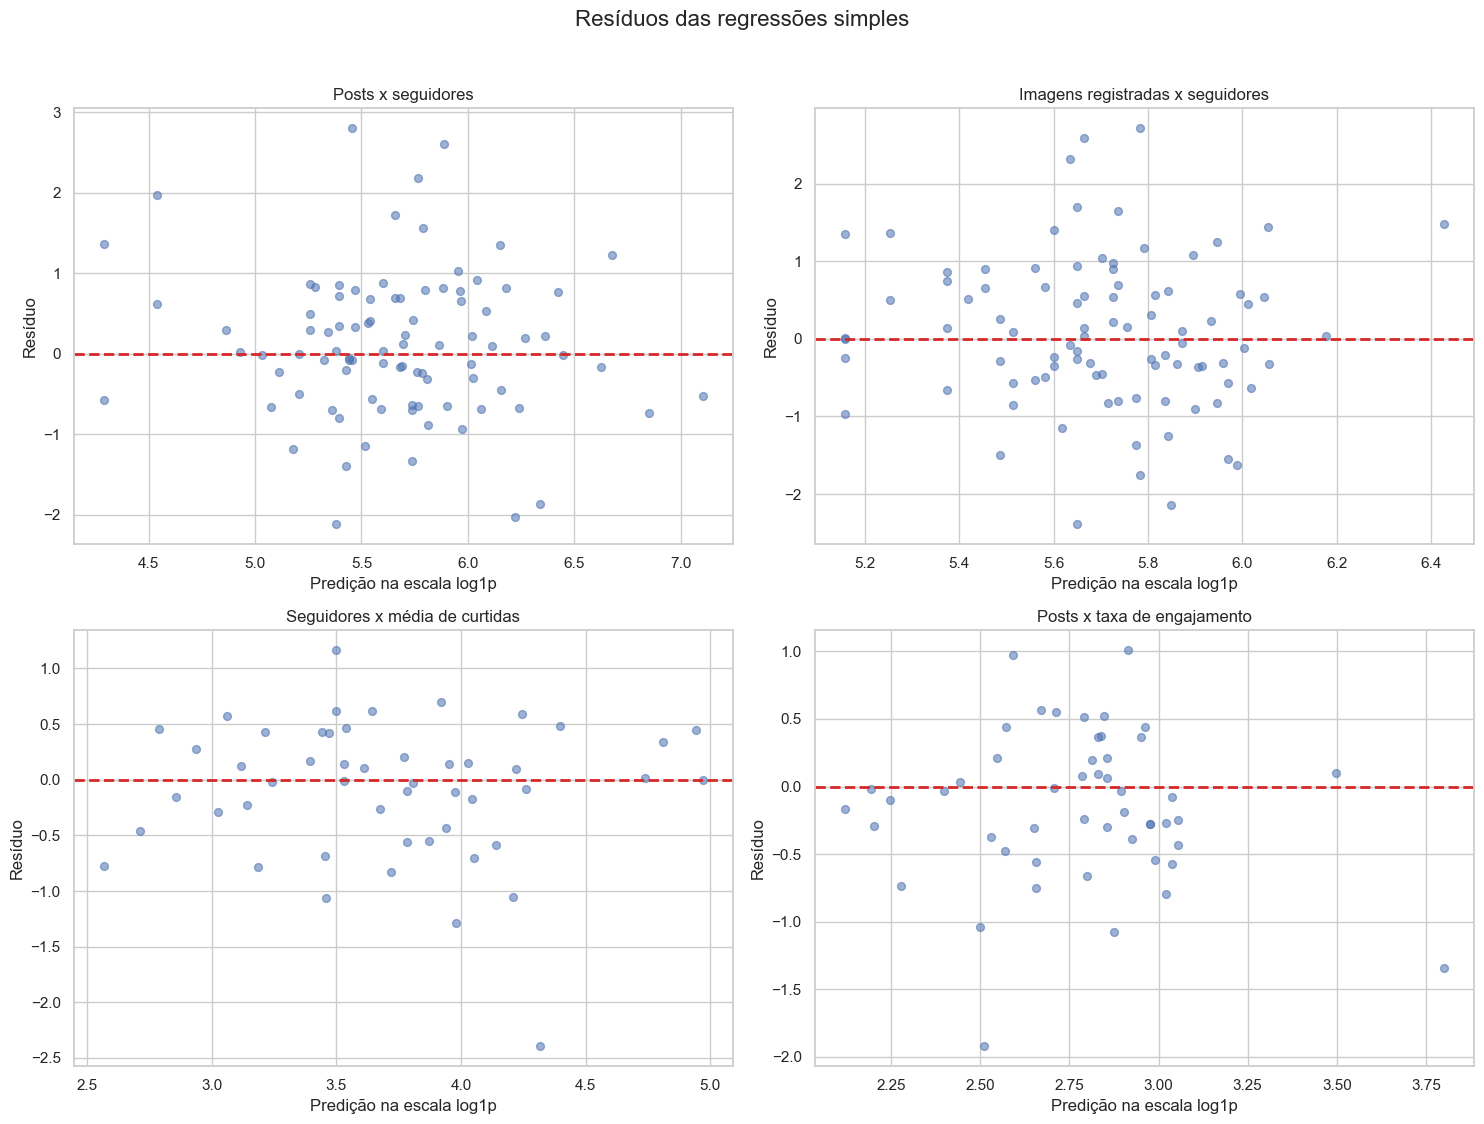

In [5]:
fig, axes = plt.subplots(2, 2, figsize=(15, 11))

for ax, (_, _, titulo) in zip(axes.flat, relacoes):
    item = modelos[titulo]
    residuos = item["y_teste"] - item["predicao"]
    ax.scatter(item["predicao"], residuos, alpha=0.55, s=32)
    ax.axhline(0, color="#d62828", linestyle="--", linewidth=2)
    ax.set_title(titulo)
    ax.set_xlabel("Predição na escala log1p")
    ax.set_ylabel("Resíduo")

plt.suptitle("Resíduos das regressões simples", fontsize=16, y=1.02)
plt.tight_layout()
plt.show()


**Como interpretar:** resíduos amplos mostram que artistas com volume semelhante podem alcançar resultados digitais muito diferentes. Portanto, os modelos servem para investigar tendências gerais, não para prever mérito, sucesso profissional ou qualidade.


## 5. Relação principal: posts e seguidores

A relação entre posts e seguidores é detalhada porque representa diretamente o limite da lógica “publique mais para alcançar mais pessoas”.


In [6]:
principal = resultados_regressao.loc[
    resultados_regressao["relação"].eq("Posts x seguidores")
].iloc[0]

print({
    "coeficiente_log": round(principal["coeficiente"], 3),
    "R²_teste": round(principal["R²_teste"], 3),
    "MAE_teste": round(principal["MAE_teste"], 3),
    "RMSE_teste": round(principal["RMSE_teste"], 3),
})


{'coeficiente_log': np.float64(0.358), 'R²_teste': np.float64(0.148), 'MAE_teste': np.float64(0.685), 'RMSE_teste': np.float64(0.909)}


## 6. Exportação do modelo principal

O modelo principal é salvo como artefato reproduzível. Ele recebe `log1p(posts_count)` e prevê `log1p(follower_count)`.


In [7]:
import joblib

MODELS_DIR = Path("../models/regressao")
MODELS_DIR.mkdir(parents=True, exist_ok=True)
joblib.dump(modelos["Posts x seguidores"]["modelo"], MODELS_DIR / "regressao_posts_seguidores.joblib")
print(f"Modelo salvo em: {MODELS_DIR / 'regressao_posts_seguidores.joblib'}")


Modelo salvo em: ..\models\regressao\regressao_posts_seguidores.joblib


## Conclusões para o FlowCarreiras

1. Volume de publicação possui associação com visibilidade, mas não explica toda a diferença entre artistas.
2. Imagens registradas, seguidores, curtidas e engajamento representam dimensões distintas.
3. Erros e resíduos elevados mostram que rankings simples seriam insuficientes e injustos.
4. Recomendações devem combinar áreas, interesses, organização do perfil e diversidade de exposição.
5. Os resultados não comprovam causalidade e refletem artistas ligados a escolas alemãs entre 2018 e 2020.
